In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/v3')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.special import softmax

from data_config import get_config

In [2]:
config = get_config('cifar100_r56')
config.par_calib = 0.1
config.num_calib = int(config.num_samples * config.par_calib)
config.plat_scale = True
randomized = False
no_zero_size_sets = True
alpha = 0.1



In [3]:
import torch.optim as optim
from tqdm import tqdm


def platt_scale(logits, labels, max_iters=100, lr=0.01, epsilon=0.005):
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(logits),
                                             torch.from_numpy(labels).long()) 
    dataloader = torch.utils.data.DataLoader(dataset,
                                             batch_size=64,
                                             shuffle=True)

    nll_criterion = nn.CrossEntropyLoss().cuda()

    T = nn.Parameter(torch.Tensor([1.]).cuda())
    optimizer = optim.SGD([T], lr=lr)
    for iter in tqdm(range(max_iters)):
        T_old = T.item()
        for x, targets in dataloader:
            optimizer.zero_grad()
            x = x.cuda()
            x.requires_grad = True
            out = x/T
            loss = nll_criterion(out, targets.long().cuda())
            loss.backward()
            optimizer.step()
        if abs(T_old - T.item()) < epsilon:
            break
    return T.item() 


In [4]:
if config.dataset_name != 'imnet1k_r152':
    with open(config.file_name, 'rb') as file:
        data = pickle.load(file)

    labels_eval, labels_calib, scores_eval, scores_calib = train_test_split(
        data["labels"], data["preds"], test_size=config.par_calib, random_state=42
    )
    if config.plat_scale:
        t = platt_scale(scores_calib, labels_calib, max_iters=100, lr=0.01, epsilon=0.005)
    else:
        t = 1.0
    print(f"Temperature: {t}")
    scores_calib = softmax(scores_calib / t, axis=1)
    scores_eval = softmax(scores_eval / t, axis=1)
    
    eval_data = {"labels": labels_eval, "scores": scores_eval}
    calib_data = {"labels": labels_calib, "scores": scores_calib}

    
else:    
    data = np.load('/home/royhirsch/conformal/data/imagenet/imagenet-resnet152.npz')
    smx = data["smx"]
    labels = data["labels"].astype(int)

    idx = np.array([1] * config.num_calib + [0] * (smx.shape[0] - config.num_calib)) > 0
    np.random.shuffle(idx)
    cal_smx, val_smx = smx[idx, :], smx[~idx, :]
    cal_labels, val_labels = labels[idx], labels[~idx]
    eval_data = {"labels": val_labels, "scores": val_smx}
    calib_data = {"labels": cal_labels, "scores": cal_smx}


 25%|██▌       | 25/100 [00:00<00:01, 45.10it/s]

Temperature: 1.9133838415145874


# Funcs

In [5]:
def calc_aps_scores(scores, labels, randomized=True):
    cal_pi = scores.argsort(1)[:, ::-1]
    cal_srt = np.take_along_axis(scores, cal_pi, axis=1).cumsum(axis=1)
    cal_softmax_correct_class = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
        range(len(labels)), labels
    ]
    if not randomized:
        cal_scores = cal_softmax_correct_class
    else:
        cumsum_index = np.where(cal_srt == cal_softmax_correct_class[:,None])[1]
        if cumsum_index.shape[0] != cal_srt.shape[0]:
            _, unique_indices = np.unique(np.where(
                cal_srt == cal_softmax_correct_class[:,None])[0], return_index=True)
            cumsum_index = cumsum_index[unique_indices]
        high = cal_softmax_correct_class
        low = np.zeros_like(high)
        low[cumsum_index != 0] = cal_srt[np.where(cumsum_index != 0)[0], cumsum_index[cumsum_index != 0]-1]
        cal_scores = np.random.uniform(low=low, high=high)
    return cal_scores


def get_aps_sets(scores, qhat, randomized=True, no_zero_size_sets=True):
    val_pi = scores.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(scores, val_pi, axis=1).cumsum(axis=1)
    if qhat.ndim:
        qhat = np.expand_dims(qhat, 1)
    if not randomized:
        prediction_sets = np.take_along_axis(val_srt <= qhat, val_pi.argsort(axis=1), axis=1)
    else:
        n_val = val_srt.shape[0]
        cumsum_index = np.sum(val_srt <= qhat, axis=1)
        cumsum_index[cumsum_index == val_smx.shape[-1]] = val_smx.shape[-1] - 1
        high = val_srt[np.arange(n_val), cumsum_index]
        low = np.zeros_like(high)
        low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
        prob = (qhat.squeeze() - low)/(high - low + 1e-10)
        prob = np.nan_to_num(prob, nan=0.0)
        prob = np.clip(prob, 0, 1)
        rv = np.random.binomial(1,prob,size=(n_val))
        randomized_threshold = low
        randomized_threshold[rv == 1] = high[rv == 1]
        if no_zero_size_sets:
            randomized_threshold = np.maximum(randomized_threshold, val_srt[:,0])
        prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)
    return prediction_sets


# Baselines APS

In [6]:
cal_smx = calib_data["scores"]
cal_labels = calib_data["labels"]
n = len(cal_labels)

val_smx = eval_data["scores"]
val_labels = eval_data["labels"]


cal_scores = calc_aps_scores(cal_smx, cal_labels, randomized)
baseline_qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
prediction_sets = get_aps_sets(val_smx, baseline_qhat, randomized, no_zero_size_sets)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), val_labels
].mean()

baseline_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Baseline mets:')
for key, value in baseline_mets.items():
    print(f"{key}: {value:.4f}")
print('Qhat: {:.4f}'.format(baseline_qhat))


Baseline mets:
size: 35.3020
coverage: 0.9142
Qhat: 0.9884


# Ours method

In [17]:
cal_scores_est = calc_aps_scores(cal_smx, cal_smx.argmax(1), randomized)
cal_scores_true = calc_aps_scores(cal_smx, cal_labels, randomized)
# cal_scores_est = np.zeros_like(cal_scores_est)
residuales = cal_scores_true - cal_scores_est

print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(residuales.mean(), residuales.std(), residuales.min(), residuales.max()))

qhat = np.quantile(
    residuales, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

print('Qhat: {:.4f}'.format(qhat))
val_scores_est = calc_aps_scores(val_smx, val_smx.argmax(1), randomized)
val_scores_true = calc_aps_scores(val_smx, val_labels, randomized)
# val_scores_est = np.zeros_like(val_scores_est)
val_scores_est = val_scores_est + qhat
print('Par of scores above 1: {:.2f}'.format(np.sum(val_scores_est > 1) / len(val_scores_est)))
val_scores_est[val_scores_est > 1] = 1
prediction_sets = get_aps_sets(val_smx, val_scores_est, randomized, no_zero_size_sets)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), val_labels
].mean()

ours_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Ours mets:')
for key, value in ours_mets.items():
    print(f"{key}: {value:.4f}")


Residuales: mean: 0.104 std: 0.171 min: 0.000 max: 0.761
Qhat: 0.3921
Par of scores above 1: 0.57
Ours mets:
size: 60.6270
coverage: 0.8813


In [15]:
def get_score_estimation(scores):
    cal_pi = scores.argsort(1)[:, ::-1]
    cal_srt = np.take_along_axis(scores, cal_pi, axis=1).cumsum(axis=1)
    cal_softmax_correct_class = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)
    return (cal_softmax_correct_class * scores).sum(1)


cal_scores_est = get_score_estimation(cal_smx)
cal_scores_true = calc_aps_scores(cal_smx, cal_labels, randomized)
# cal_scores_est = np.zeros_like(cal_scores_est)
residuales = cal_scores_true - cal_scores_est

print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(residuales.mean(), residuales.std(), residuales.min(), residuales.max()))

qhat = np.quantile(
    residuales, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)

print('Qhat: {:.4f}'.format(qhat))
val_scores_est = get_score_estimation(val_smx)
val_scores_true = calc_aps_scores(val_smx, val_labels, randomized)
# val_scores_est = np.zeros_like(val_scores_est)
val_scores_est = val_scores_est + qhat
print('Par of scores above 1: {:.2f}'.format(np.sum(val_scores_est > 1) / len(val_scores_est)))
val_scores_est[val_scores_est > 1] = 1
prediction_sets = get_aps_sets(val_smx, val_scores_est, randomized, no_zero_size_sets)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), val_labels
].mean()

ours_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Ours mets:')
for key, value in ours_mets.items():
    print(f"{key}: {value:.4f}")


Residuales: mean: -0.001 std: 0.134 min: -0.401 max: 0.419
Qhat: 0.1851
Par of scores above 1: 0.42
Ours mets:
size: 47.1719
coverage: 0.8859


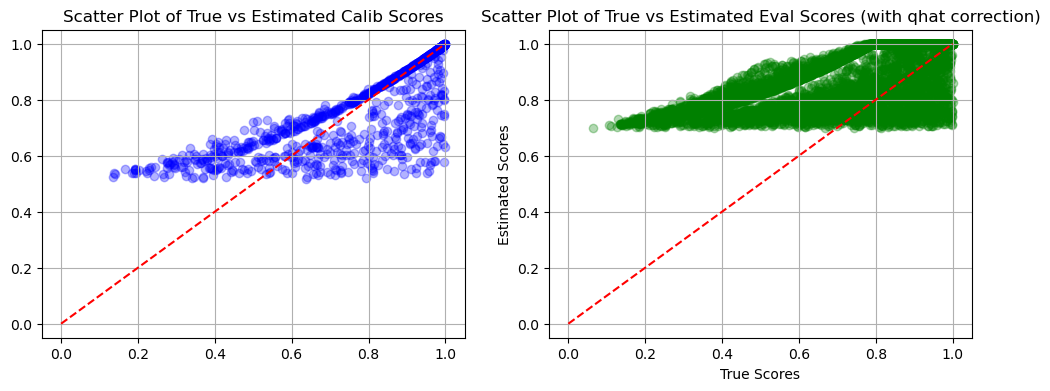

Text(0.5, 1.0, 'Estimated eval scores')

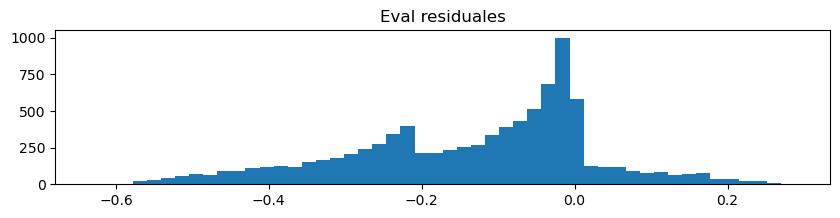

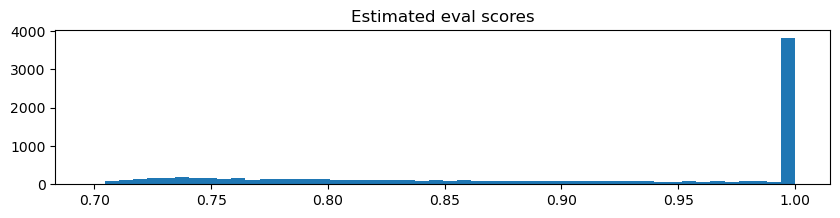

In [9]:
# debug #
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(cal_scores_true, cal_scores_est, color='blue', alpha=0.3)
ax[0].set_title('Scatter Plot of True vs Estimated Calib Scores')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].grid(True)

ax[1].scatter(val_scores_true, val_scores_est, color='green', alpha=0.3)
ax[1].set_title('Scatter Plot of True vs Estimated Eval Scores (with qhat correction)')
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].grid(True)
plt.show()

plt.figure(figsize=(10, 2))
_ = plt.hist(val_scores_true - val_scores_est, bins=50)
plt.title('Eval residuales')

plt.figure(figsize=(10, 2))
_ = plt.hist(val_scores_est, bins=50)
plt.title('Estimated eval scores')

# Ours 2 groups

In [10]:
above_calib_inds = np.where(cal_smx.max(1) > 1. - alpha)[0]
below_calib_inds = np.where(cal_smx.max(1) <= 1. - alpha)[0]
print(len(above_calib_inds), len(below_calib_inds))

cal_scores_above_est = calc_aps_scores(cal_smx[above_calib_inds, :], cal_smx.argmax(1)[above_calib_inds], randomized)
residuales_above = calc_aps_scores(cal_smx[above_calib_inds, :], cal_labels[above_calib_inds], randomized) - cal_scores_above_est
print('ABOVE')
print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(
    residuales_above.mean(), residuales_above.std(), residuales_above.min(), residuales_above.max()))

qhat_above = np.quantile(
    residuales_above, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
print('Qhat: {:.4f}'.format(qhat_above))


cal_scores_below_est = calc_aps_scores(cal_smx[below_calib_inds, :], cal_smx.argmax(1)[below_calib_inds], randomized)
residuales_below = calc_aps_scores(cal_smx[below_calib_inds, :], cal_labels[below_calib_inds], randomized) - cal_scores_below_est
print('BELOW')
print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(
    residuales_below.mean(), residuales_below.std(), residuales_below.min(), residuales_below.max()))

qhat_below = np.quantile(
    residuales_below, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)
print('Qhat: {:.4f}'.format(qhat_below))


304 696
ABOVE
Residuales: mean: 0.001 std: 0.007 min: 0.000 max: 0.079
Qhat: 0.0000
BELOW
Residuales: mean: 0.148 std: 0.189 min: 0.000 max: 0.761
Qhat: 0.4436


In [11]:
above_val_inds = np.where(val_smx.argmax(1) > 1. - alpha)[0]
below_val_inds = np.where(val_smx.argmax(1) <= 1. - alpha)[0]

val_scores_above_est = calc_aps_scores(val_smx[above_val_inds, :], val_smx[above_val_inds, :].argmax(1), randomized)
val_scores_above_est = val_scores_above_est + qhat_above
print('Par of scores above 1 (above fold): {:.2f}'.format(np.sum(val_scores_above_est > 1) / len(val_scores_above_est)))
val_scores_above_est[val_scores_above_est > 1] = 1
prediction_sets_above = get_aps_sets(val_smx[above_val_inds, :], val_scores_above_est, randomized, no_zero_size_sets)

val_scores_below_est = calc_aps_scores(val_smx[below_val_inds, :], val_smx[below_val_inds, :].argmax(1), randomized)
val_scores_below_est = val_scores_below_est + qhat_below
print('Par of scores above 1 (below fold): {:.2f}'.format(np.sum(val_scores_below_est > 1) / len(val_scores_below_est)))
val_scores_below_est[val_scores_below_est > 1] = 1
prediction_sets_below = get_aps_sets(val_smx[below_val_inds, :], val_scores_below_est, randomized, no_zero_size_sets)

empirical_coverage = np.concatenate([
    prediction_sets_above[np.arange(prediction_sets_above.shape[0]), val_labels[above_val_inds]],
    prediction_sets_below[np.arange(prediction_sets_below.shape[0]), val_labels[below_val_inds]],
]).mean()

ours_two_groups_mets = {
    "size": np.concatenate([
        prediction_sets_above,
        prediction_sets_below,
        ]).sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Ours two groups mets:')
for key, value in ours_two_groups_mets.items():
    print(f"{key}: {value:.4f}")

print('Above {}/{}'.format(len(above_val_inds), len(val_labels)))
print('Size: {:.4f} coverage: {:.4f}'.format(
    prediction_sets_above.sum(1).mean(),
    prediction_sets_above[np.arange(prediction_sets_above.shape[0]), val_labels[above_val_inds]].mean()))

print('Below {}/{}'.format(len(below_val_inds), len(val_labels)))
print('Size: {:.4f} coverage: {:.4f}'.format(
    prediction_sets_below.sum(1).mean(),
    prediction_sets_below[np.arange(prediction_sets_below.shape[0]), val_labels[below_val_inds]].mean()))

Par of scores above 1 (above fold): 0.00
Par of scores above 1 (below fold): 0.66
Ours two groups mets:
size: 1.6097
coverage: 0.6373
Above 8921/9000
Size: 1.0000 coverage: 0.6341
Below 79/9000
Size: 70.4557 coverage: 1.0000


# Results

In [12]:
import pandas as pd

metrics_list = [baseline_mets, ours_mets, ours_two_groups_mets]

df = pd.DataFrame(columns=['Method', 'Size', 'Coverage'])
df.loc[0] = ['Baseline', baseline_mets['size'], baseline_mets['coverage']]
df.loc[1] = ['Ours', ours_mets['size'], ours_mets['coverage']]
df.loc[2] = ['Ours groups', ours_two_groups_mets['size'], ours_two_groups_mets['coverage']]
print(df)

        Method       Size  Coverage
0     Baseline  35.302000  0.914222
1         Ours  47.171889  0.885889
2  Ours groups   1.609667  0.637333
